In [1]:
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel, LSTMModel, DecoupledGCNModel

epiconfig= EpiConfig(
        disease             = 'influenza',

        horizon_leadtime    = 9,
        sequence_length     = 4,
        feature_popsize     = False,      
        feature_popdens     = True,
        min_date='2012-06-01',
        # feature_gisd        = True,
        # feature_popage      = True,
        # feature_kreise_classes= True,
        
        log_transform       = ['incidence']     
        )    

data_orch= EpiDataOrchestrator(epiconfig).build()

In [2]:
from src.dataloading.dataloaders import BaseLineDataLoaderManager, DeepDataLoaderManager,GraphDataLoaderManager

n_epochs        = 10
lr              = 0.1
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 2,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orch)
deepdataloader      = DeepDataLoaderManager(data_orch).build()
# graphloader1        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph1').build()
# graphloader2        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph2').build()
# graphloader3        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph3').build()
# graphloader4        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph4').build()
# graphloader5        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph5').build()
# graphloader6        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph6').build()
# graphloader10       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph10').build()
# graphloader13       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph13').build()
# graphloader16       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph16').build()

model_initialized ✓
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   2.2082   |   2.8149   |    v     |           |


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel/training.py:218: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 2 epochs
Restored model from best validation loss: 2.8149


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 1708.57it/s]


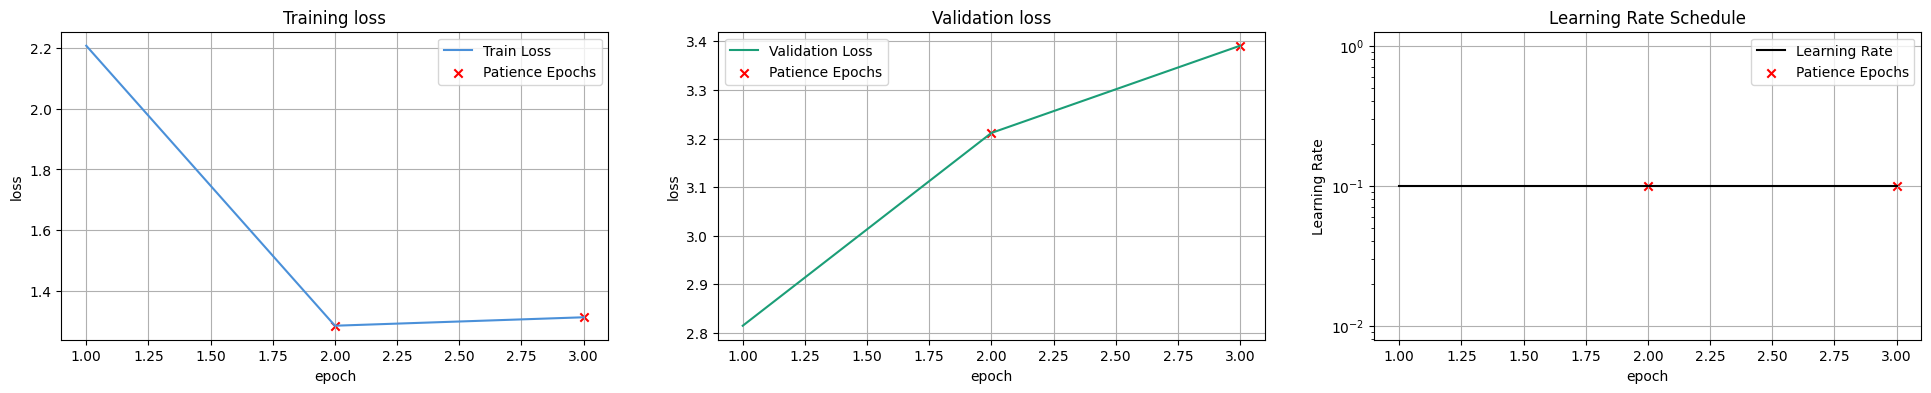

In [3]:
from src.models import LSTMModel

lstm = LSTMModel(deepdataloader, name = 'lstm-hl9-s456.pt', verbose = 1)
lstm.set_model_hparams(hidden_size=128, dropout = 0.3)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')



/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel/training.py:218: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


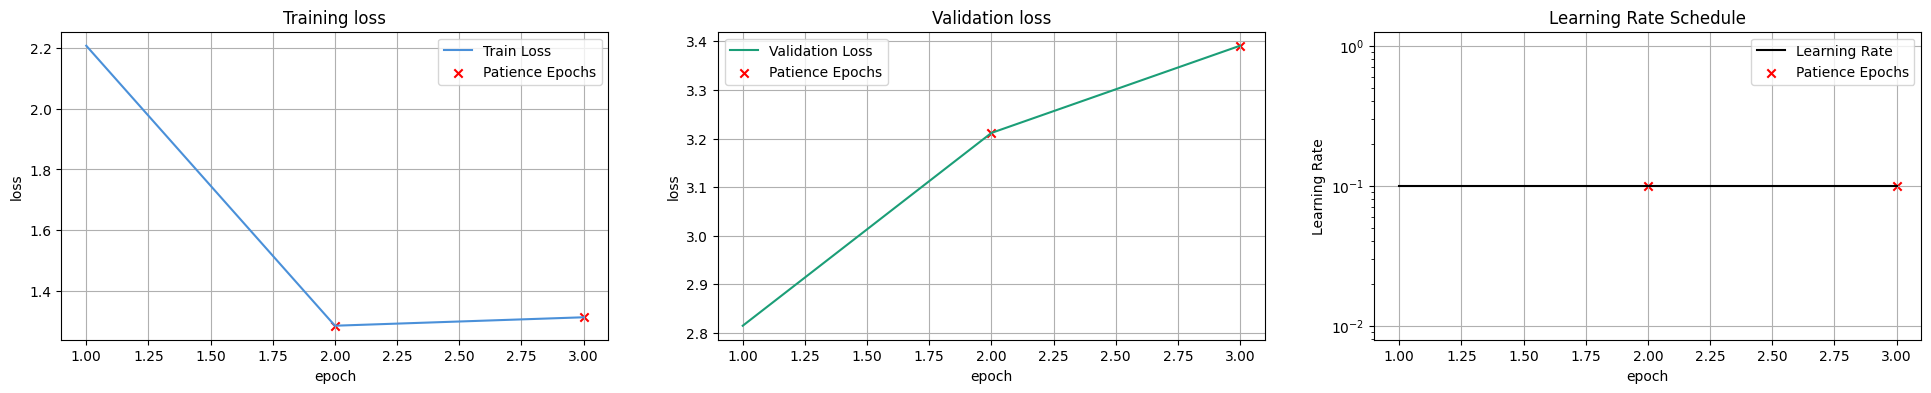

In [4]:
lstm.show_monitoring_metrics()

In [5]:
from src.models import GCN2Model

# identity graph. self loops will be False
gcn1 = GCN2Model(graphloader1, name = 'gcn1', verbose = 2)
gcn1.set_model_hparams(dropout = 0.3, self_loops=False)
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
gcn1.show_forecasts(26)

NameError: name 'graphloader1' is not defined


==                     gcn2                     ==
Dataloader:GraphDataList(387 datapoints, sample: x=(400, 5, 4), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.2417   |   1.9230   |    v     |           |
|  002  |   0.9904   |   1.4422   |    v     |           |
|  003  |   0.8505   |   1.0725   |    v     |           |
|  004  |   0.7594   |   0.8637   |    v     |           |
|  005  |   0.7139   |   0.7563   |    v     |           |
|  006  |   0.6942   |   0.7034   |    v     |           |
|  007  |   0.6722   |   0.6662   |    v     |           |
|  008  |   0.6612   |   0.6447   |    v     |           |
|  009  |   0.6497   |   0.6245   |    v     |           |
|  010  |   0.6372   |   0.6073   |    v     |           |
|  011  |   0.6335   |   0.5940   |    v     |           |
|  012  |   0.6214   |   0.5846   |    v     |           |
|  

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel/training.py:218: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  020  |   0.5824   |   0.5440   |    v     |           |


Forecasting test: 100%|███████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 571.84it/s]

Test loss: 0.7763


<Fig(n_axes = 1, legend, ticks, labels)>

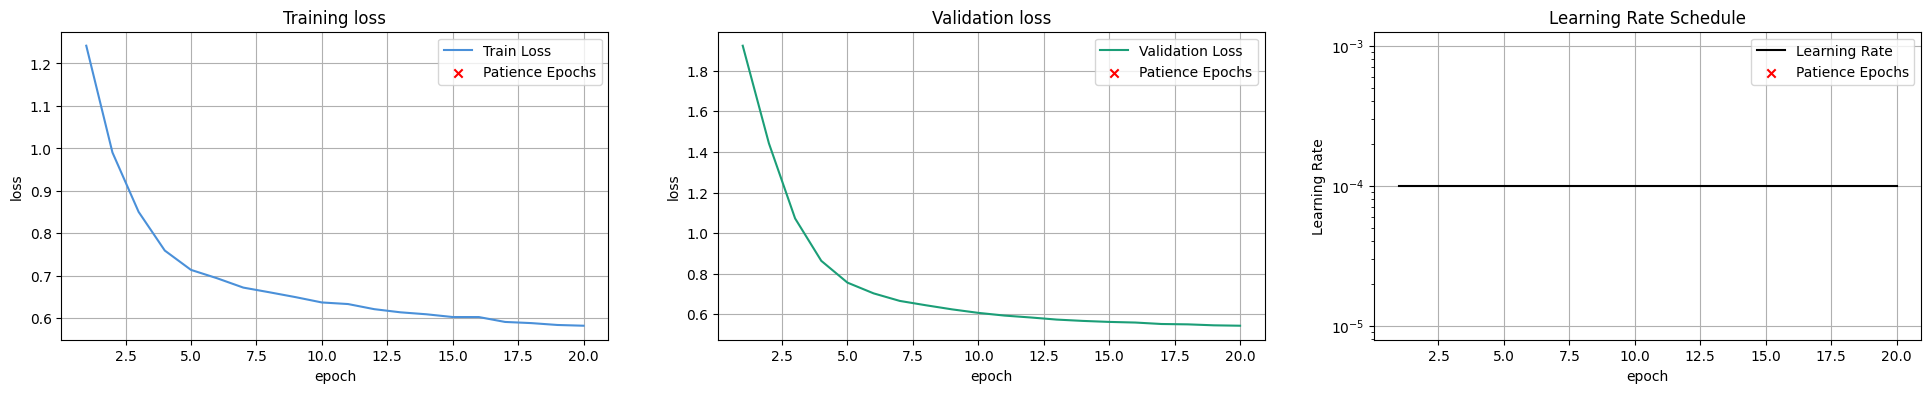

In [ ]:
gcn2 = GCN2Model(graphloader2, name = 'gcn2', verbose = 2)
gcn2.set_model_hparams(dropout = 0.3, self_loops=False)
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')


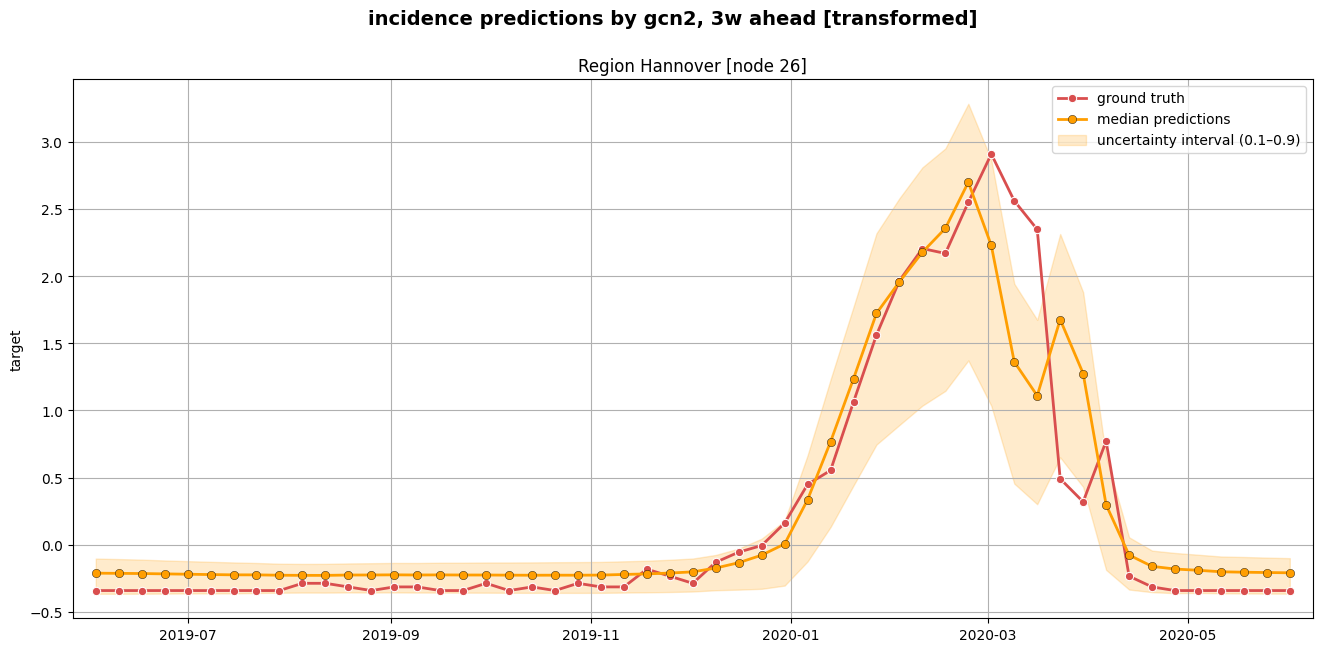

In [ ]:
gcn2.show_forecasts(26, is_original=False).show()


==                     gcn3                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 12), y=(400, 1), edge_index=(2, 1294), edge_weight=(1294,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9234   |   1.1056   |    v     |           |
|  002  |   0.7511   |   0.8552   |    v     |           |
|  003  |   0.6568   |   0.7193   |    v     |           |
|  004  |   0.6090   |   0.6552   |    v     |           |
|  005  |   0.5816   |   0.6166   |    v     |           |
|  006  |   0.5666   |   0.5918   |    v     |           |
|  007  |   0.5492   |   0.5711   |    v     |           |
|  008  |   0.5398   |   0.5513   |    v     |           |
|  009  |   0.5305   |   0.5409   |    v     |           |
|  010  |   0.5167   |   0.5231   |    v     |           |
|  011  |   0.5077   |   0.5104   |    v     |           |
|  012  |   0.5016   |   0.5005   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4252
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 644.48it/s]

Test loss: 0.5663
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

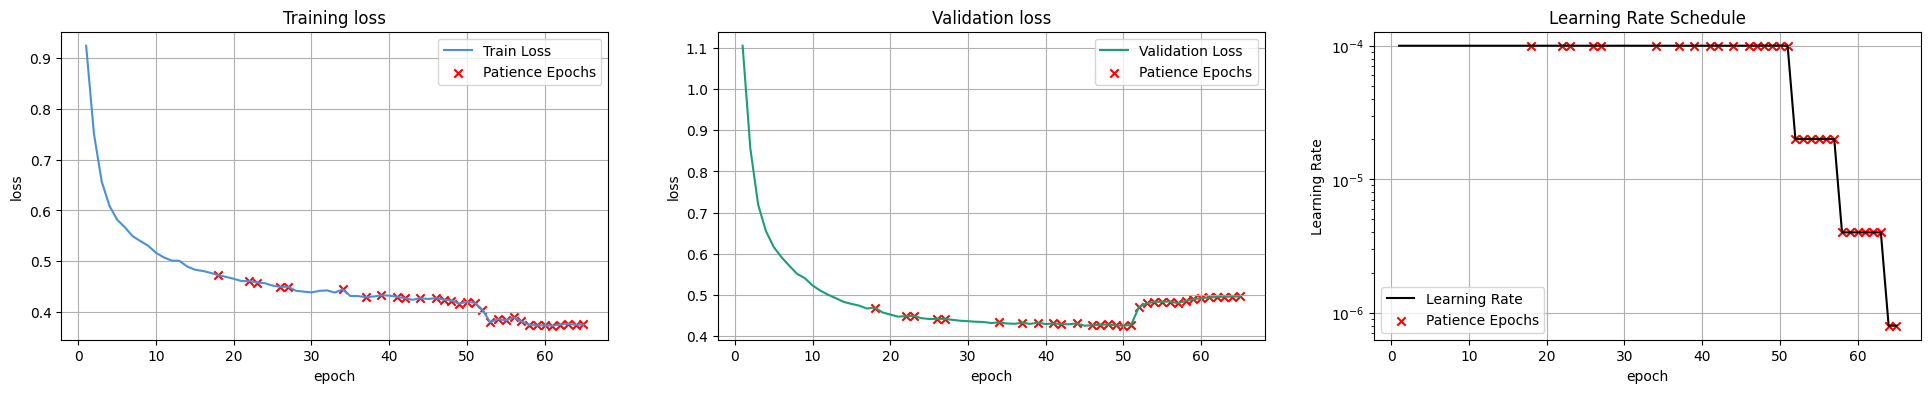

In [ ]:
gcn3 = GCN2Model(graphloader3, name = 'gcn3', verbose = 2)
gcn3.set_model_hparams(dropout = 0.3, self_loops=False)
gcn3.set_global_hparams(**global_hparams)
gcn3.train()
gcn3.forecast('test')
gcn3.show_forecasts(26)

In [ ]:
# gcn4 = GCN2Model(graphloader4, name = 'gcn4', verbose = 2)
# gcn4.set_model_hparams(dropout = 0.3, self_loops=False)
# gcn4.set_global_hparams(**global_hparams)
# gcn4.train()
# gcn4.forecast('test')
# gcn4.show_forecasts(26)

In [ ]:
# gcn5 = GCN2Model(graphloader5, name = 'gcn5', verbose = 2)
# gcn5.set_model_hparams(dropout = 0.3, self_loops=False)
# gcn5.set_global_hparams(**global_hparams)
# gcn5.train()
# gcn5.forecast('test')
# gcn5.show_forecasts(26)

In [ ]:
# gcn6 = GCN2Model(graphloader6, name = 'gcn6', verbose = 2)
# gcn6.set_model_hparams(dropout = 0.3, self_loops=False)
# gcn6.set_global_hparams(**global_hparams)
# gcn6.train()
# gcn6.forecast('test')
# gcn6.show_forecasts(26)


==                    gcn10                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 12), y=(400, 1), edge_index=(2, 1047), edge_weight=(1047,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9451   |   1.2046   |    v     |           |
|  002  |   0.7684   |   0.9532   |    v     |           |
|  003  |   0.6760   |   0.7823   |    v     |           |
|  004  |   0.6150   |   0.7056   |    v     |           |
|  005  |   0.5857   |   0.6409   |    v     |           |
|  006  |   0.5673   |   0.6030   |    v     |           |
|  007  |   0.5487   |   0.5816   |    v     |           |
|  008  |   0.5347   |   0.5604   |    v     |           |
|  009  |   0.5188   |   0.5324   |    v     |           |
|  010  |   0.5142   |   0.5160   |    v     |           |
|  011  |   0.5049   |   0.5055   |    v     |           |
|  012  |   0.4967   |   0.4927   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 650.00it/s]


Test loss: 0.5732
forecasted ✓

==                    gcn13                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 12), y=(400, 1), edge_index=(2, 2094), edge_weight=(2094,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8752   |   1.1447   |    v     |           |
|  002  |   0.7199   |   0.8890   |    v     |           |
|  003  |   0.6319   |   0.7200   |    v     |           |
|  004  |   0.5786   |   0.6311   |    v     |           |
|  005  |   0.5571   |   0.5702   |    v     |           |
|  006  |   0.5377   |   0.5276   |    v     |           |
|  007  |   0.5249   |   0.5077   |    v     |           |
|  008  |   0.5134   |   0.4840   |    v     |           |
|  009  |   0.4955   |   0.4679   |    v     |           |
|  010  |   0.4970   |   0.4546   |    v     |           |
|  011  |   0.4866   |   0.4460   |    v     |           |
|  012 

...

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3725
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 652.58it/s]

Test loss: 0.5290
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

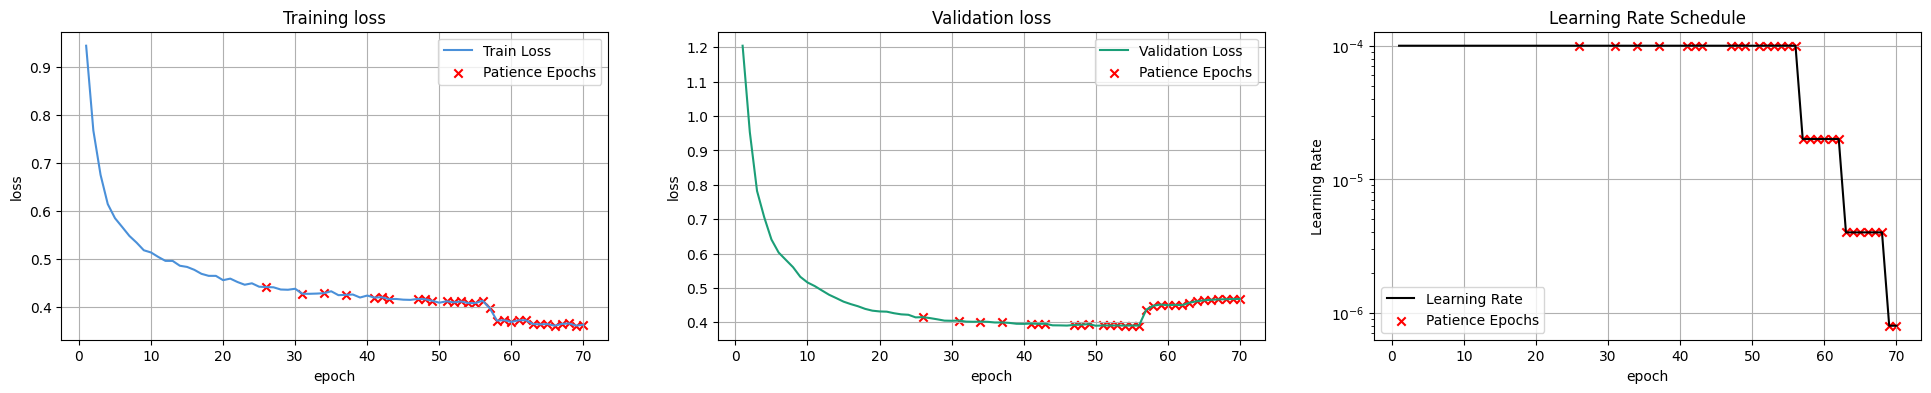

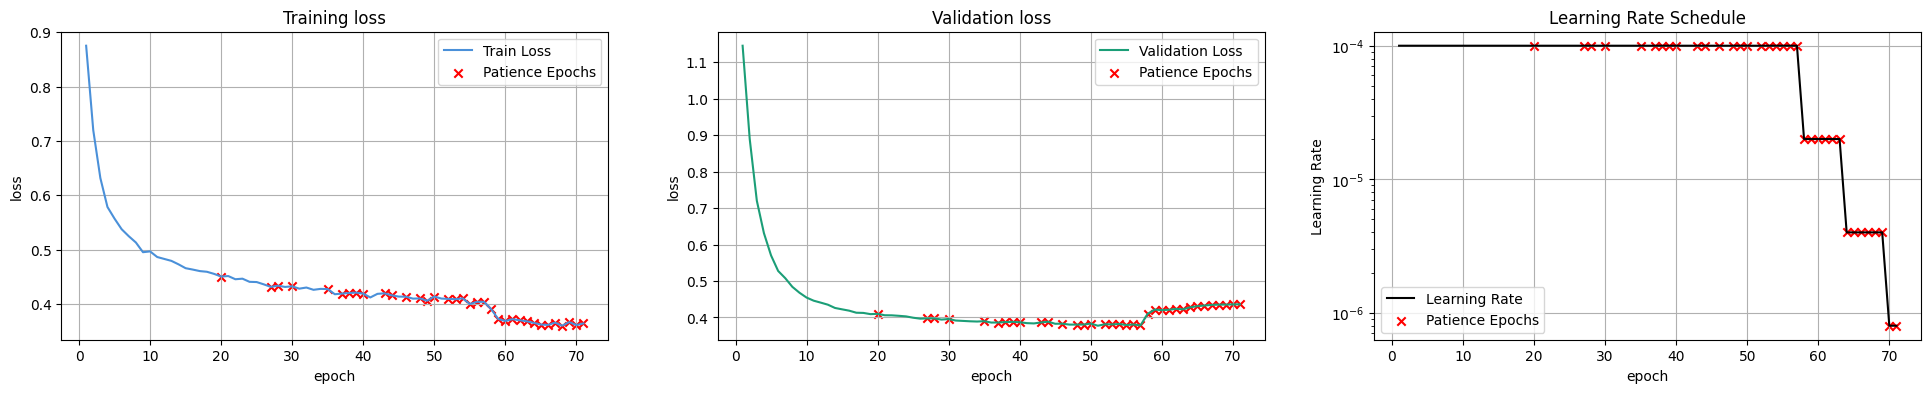

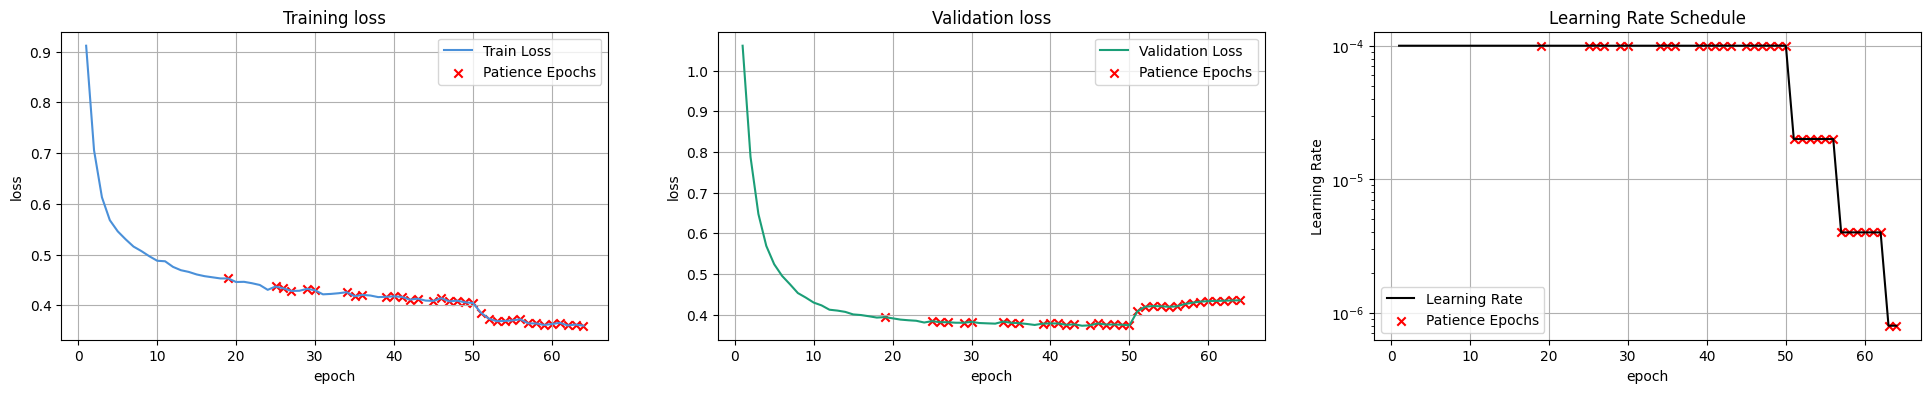

In [ ]:
gcn10 = GCN2Model(graphloader10, name = 'gcn10', verbose = 2)
gcn10.set_model_hparams(dropout = 0.3, self_loops=False)
gcn10.set_global_hparams(**global_hparams)
gcn10.train()
gcn10.forecast('test')
gcn10.show_forecasts(26)

gcn13 = GCN2Model(graphloader13, name = 'gcn13', verbose = 2)
gcn13.set_model_hparams(dropout = 0.3, self_loops=False)
gcn13.set_global_hparams(**global_hparams)
gcn13.train()
gcn13.forecast('test')
gcn13.show_forecasts(26)

gcn16 = GCN2Model(graphloader16, name = 'gcn16', verbose = 2)
gcn16.set_model_hparams(dropout = 0.3, self_loops=False)
gcn16.set_global_hparams(**global_hparams)
gcn16.train()
gcn16.forecast('test')
gcn16.show_forecasts(26)


==                    dcgcn1                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 12), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9221   |   1.3251   |    v     |           |
|  002  |   0.7237   |   0.8595   |    v     |           |
|  003  |   0.6174   |   0.6958   |    v     |           |
|  004  |   0.5806   |   0.5898   |    v     |           |
|  005  |   0.5515   |   0.5383   |    v     |           |
|  006  |   0.5388   |   0.5056   |    v     |           |
|  007  |   0.5266   |   0.4818   |    v     |           |
|  008  |   0.5146   |   0.4686   |    v     |           |
|  009  |   0.5067   |   0.4633   |    v     |           |
|  010  |   0.4987   |   0.4538   |    v     |           |
|  011  |   0.4871   |   0.4457   |    v     |           |
|  012  |   0.4902   |   0.4382   |    v

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4016
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 433.96it/s]


Test loss: 0.6080
forecasted ✓

==                    dcgcn2                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 12), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9198   |   1.0650   |    v     |           |
|  002  |   0.6808   |   0.7629   |    v     |           |
|  003  |   0.6091   |   0.6365   |    v     |           |
|  004  |   0.5804   |   0.5646   |    v     |           |
|  005  |   0.5510   |   0.5197   |    v     |           |
|  006  |   0.5353   |   0.4841   |    v     |           |
|  007  |   0.5159   |   0.4600   |    v     |           |
|  008  |   0.5046   |   0.4430   |    v     |           |
|  009  |   0.4925   |   0.4303   |    v     |           |
|  010  |   0.4842   |   0.4228   |    v     |           |
|  011  |   0.4764   |   0.4126   |    v     |           |
|  012 

...

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3800
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 431.15it/s]

Test loss: 0.5763
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

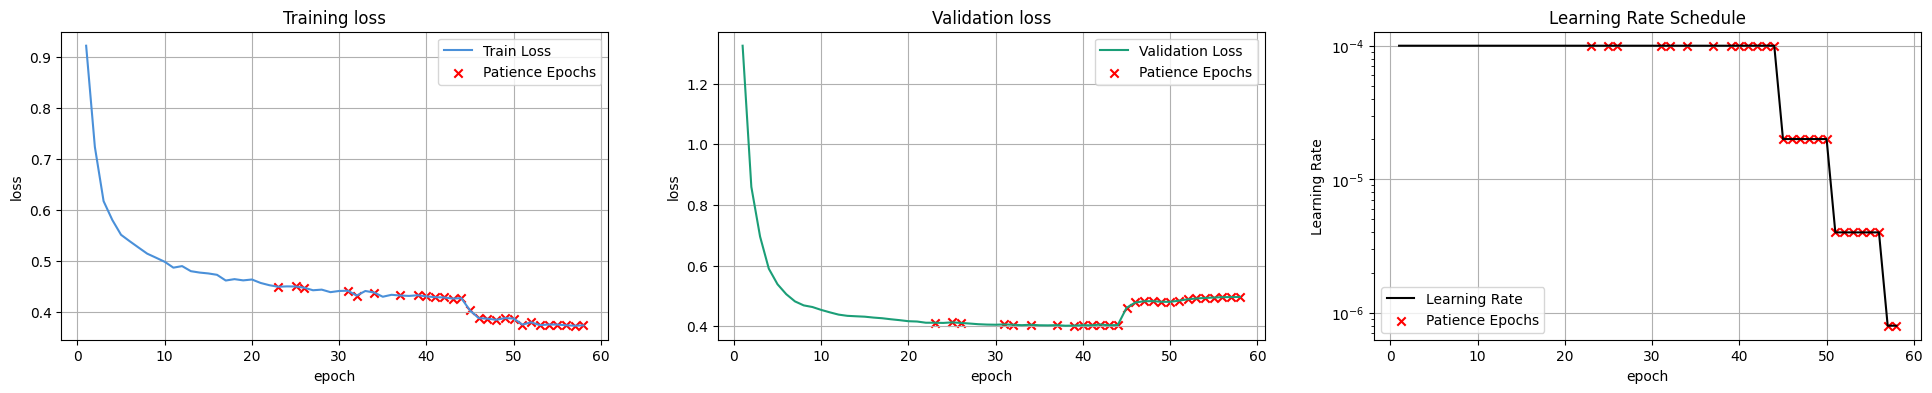

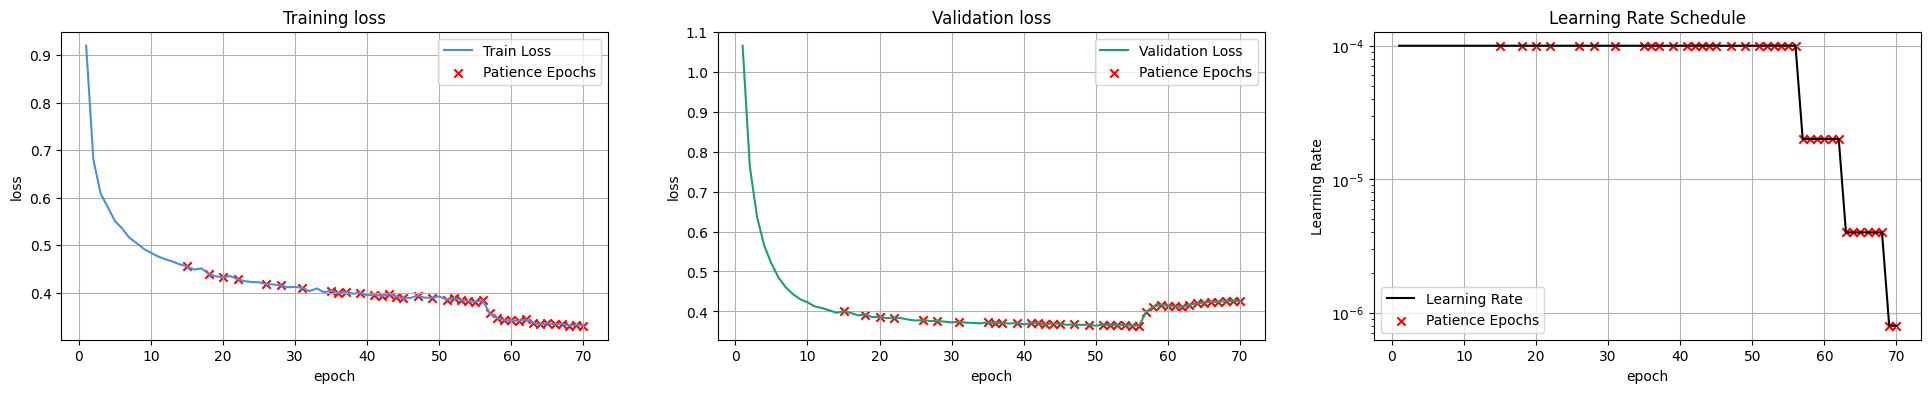

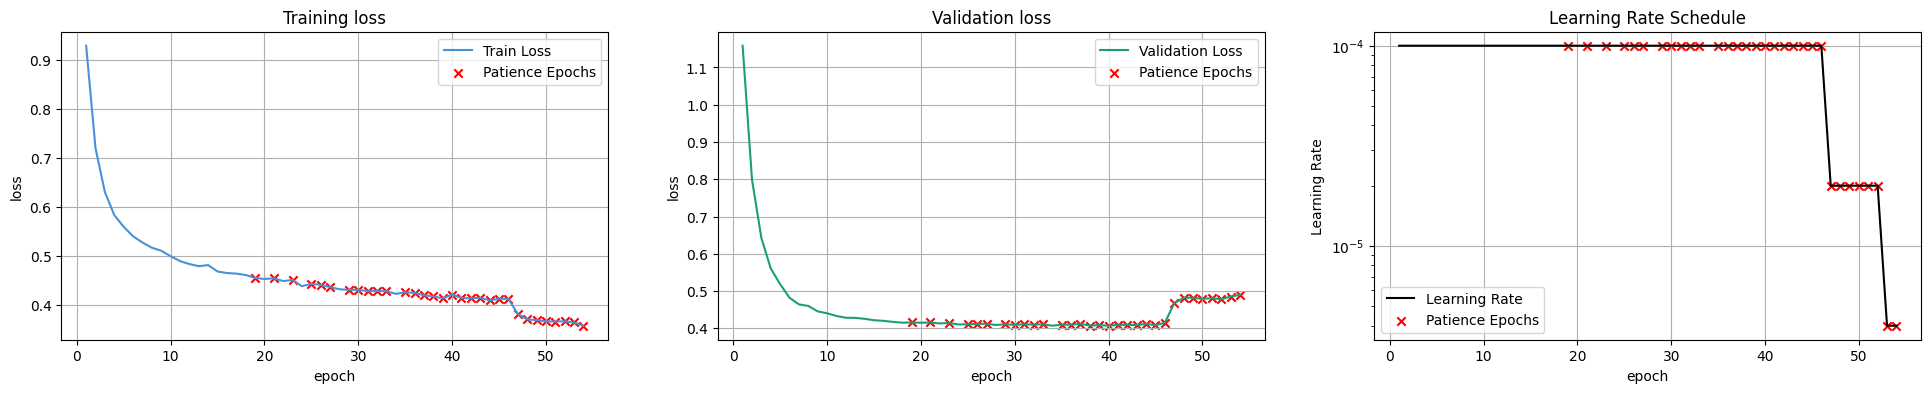

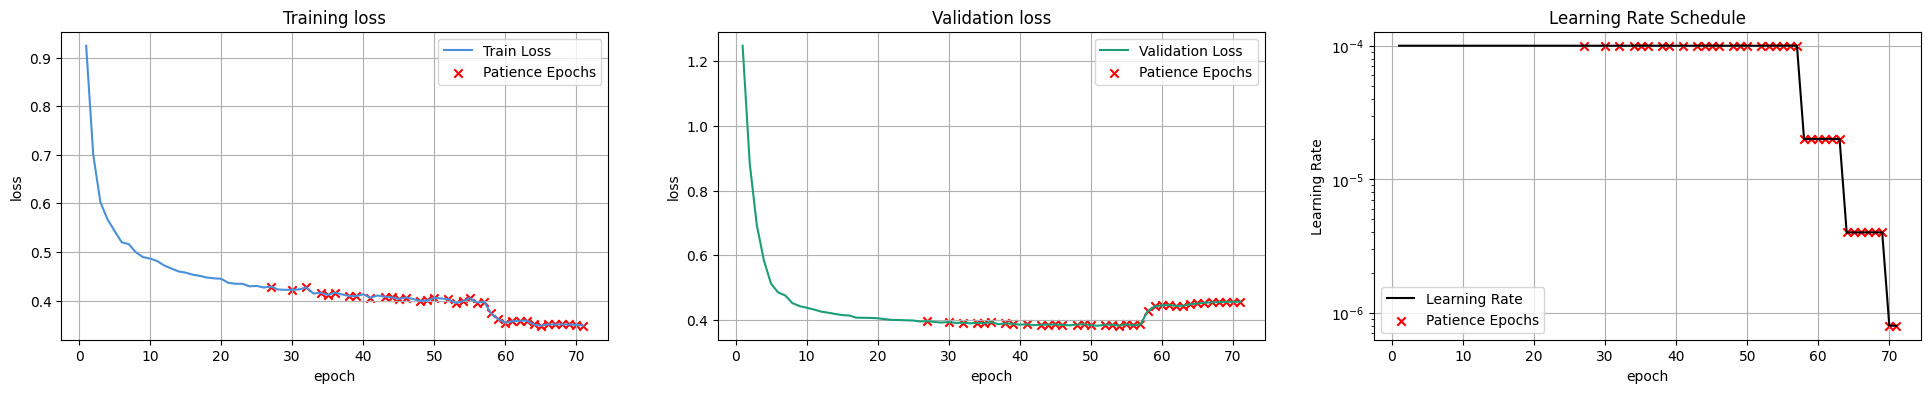

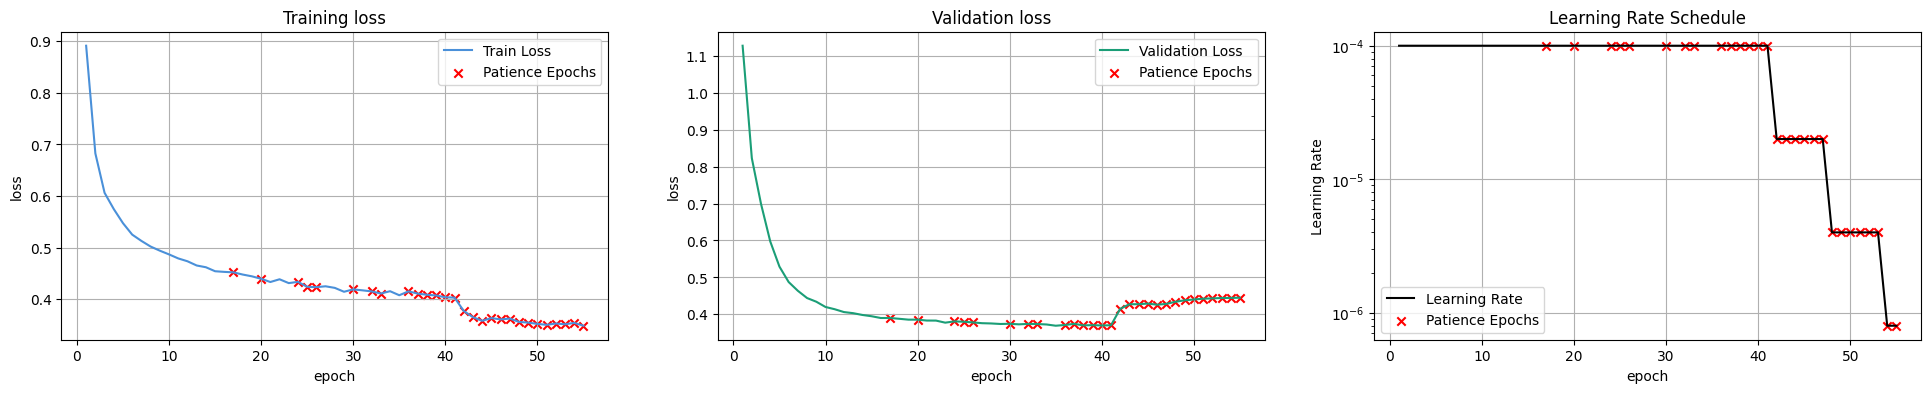

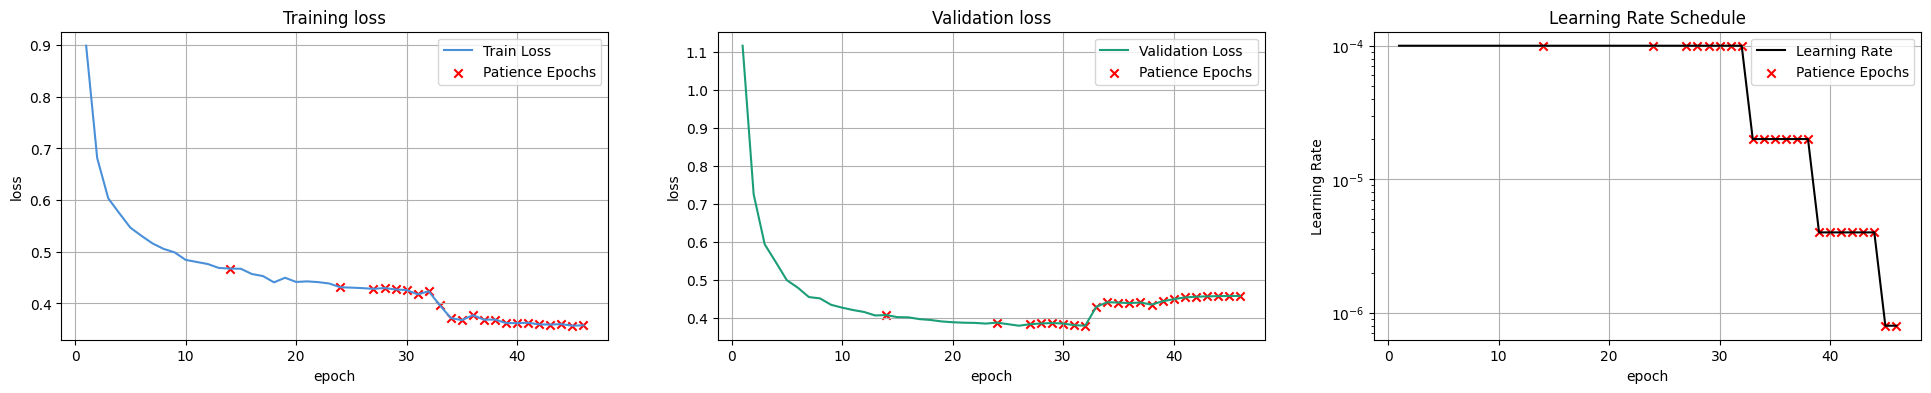

In [ ]:
from src.models import DecoupledGCNModel

dcgcn1 = DecoupledGCNModel(graphloader1, name = 'dcgcn1', verbose = 2)
dcgcn1.set_model_hparams(dropout = 0.3)
dcgcn1.set_global_hparams(**global_hparams)
dcgcn1.train()
dcgcn1.forecast('test')
dcgcn1.show_forecasts(26)

dcgcn2 = DecoupledGCNModel(graphloader2, name = 'dcgcn2', verbose = 2)
dcgcn2.set_model_hparams(dropout = 0.3)
dcgcn2.set_global_hparams(**global_hparams)
dcgcn2.train()
dcgcn2.forecast('test')
dcgcn2.show_forecasts(26)

dcgcn3 = DecoupledGCNModel(graphloader3, name = 'dcgcn3', verbose = 2)
dcgcn3.set_model_hparams(dropout = 0.3)
dcgcn3.set_global_hparams(**global_hparams)
dcgcn3.train()
dcgcn3.forecast('test')
dcgcn3.show_forecasts(26)

dcgcn10 = DecoupledGCNModel(graphloader10, name = 'dcgcn10', verbose = 2)
dcgcn10.set_model_hparams(dropout = 0.3)
dcgcn10.set_global_hparams(**global_hparams)
dcgcn10.train()
dcgcn10.forecast('test')
dcgcn10.show_forecasts(26)

dcgcn13 = DecoupledGCNModel(graphloader13, name = 'dcgcn13', verbose = 2)
dcgcn13.set_model_hparams(dropout = 0.3)
dcgcn13.set_global_hparams(**global_hparams)
dcgcn13.train()
dcgcn13.forecast('test')
dcgcn13.show_forecasts(26)

dcgcn16 = DecoupledGCNModel(graphloader16, name = 'dcgcn16', verbose = 2)
dcgcn16.set_model_hparams(dropout = 0.3)
dcgcn16.set_global_hparams(**global_hparams)
dcgcn16.train()
dcgcn16.forecast('test')
dcgcn16.show_forecasts(26)

In [ ]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedataloader)
persistence.forecast()

climateology = ClimateologyModel(baselinedataloader)
climateology.forecast()

climascale = ClimaScaleModel(baselinedataloader)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

In [ ]:
gcn_models = [gcn1, gcn2, gcn3, gcn10, gcn13, gcn16]
dcgcn_models=[dcgcn1, dcgcn2, dcgcn3, dcgcn10, dcgcn13, dcgcn16]

models = baseline_models + gcn_models + dcgcn_models + [lstm]

model_evaluation = Evaluator(models).add_evaluation()

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:08<00:00, 765.56it/s]


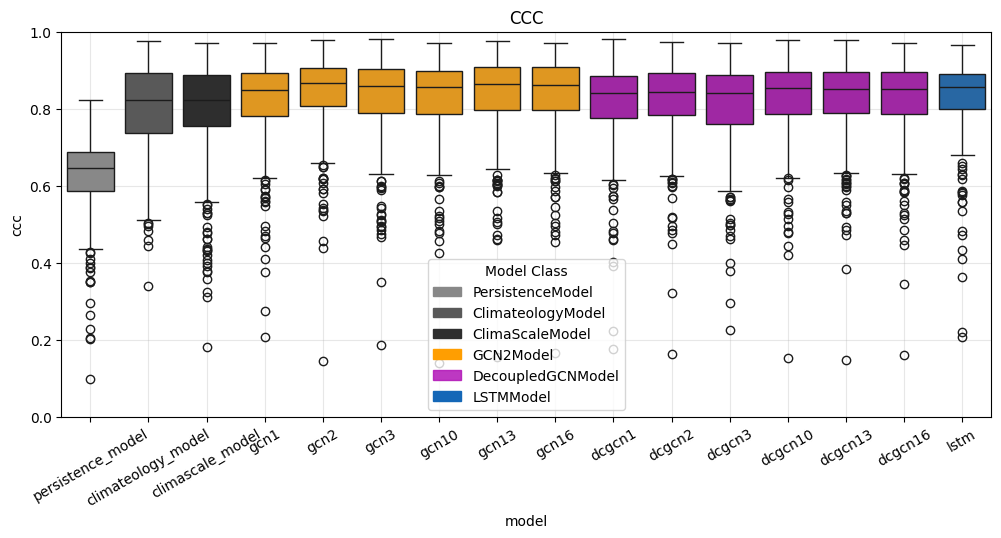

In [ ]:
model_evaluation.plotter.plot_metric(0,'test', 'ccc',plot_type = 'box', log=False, vmin = 0, vmax = 1).show()

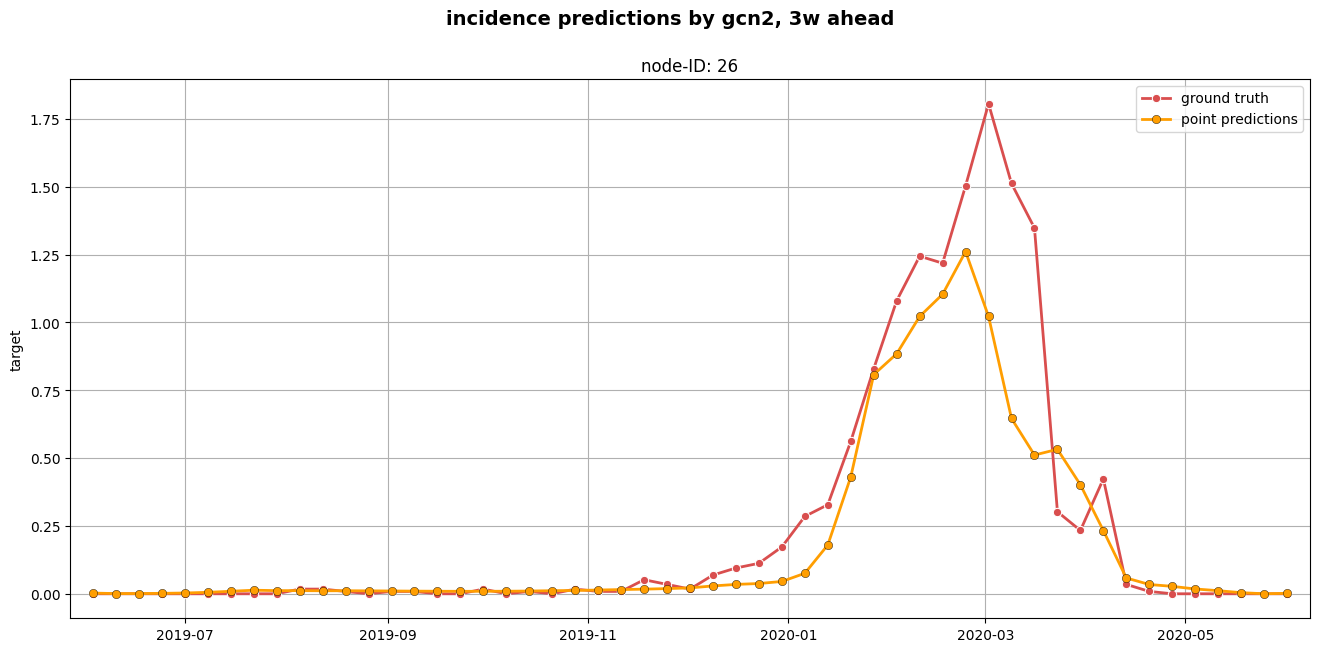

In [ ]:
gcn2.show_forecasts(26).show()

In [ ]:
import pandas as pd

def describe_evaluation(metrics: pd.DataFrame, persistence_name: str = 'persistence_model') -> None:
    """
    Print a structured summary of evaluation results for diagnostic purposes.
    """
    models = metrics['model'].unique().tolist()
    
    print("=" * 60)
    print("MODELS")
    print("=" * 60)
    print(metrics['model'].unique().tolist())
    print(f"n nodes: {metrics['node'].nunique()}")
    print()

    print("=" * 60)
    print("GLOBAL CCC PER MODEL")
    print("=" * 60)
    summary = (
        metrics.groupby('model')['ccc']
        .agg(['mean','median','std', 
              lambda x: (x > 0).mean()])
        .round(4)
    )
    summary.columns = ['mean', 'median', 'std', 'frac_positive']
    print(summary.to_string())
    print()

    print("=" * 60)
    print("CCC RELATIVE TO PERSISTENCE (mean delta per model)")
    print("=" * 60)
    persistence_ccc = metrics[metrics['model'] == persistence_name][['node','ccc']].rename(columns={'ccc':'ccc_persistence'})
    merged = metrics.merge(persistence_ccc, on='node', how='inner')
    merged['delta'] = merged['ccc'] - merged['ccc_persistence']

    for model in models:
        if model == persistence_name:
            continue
        m = merged[merged['model'] == model]
        print(f"  {model:<30}  mean_delta={m['delta'].mean():+.4f}  "
            f"median_delta={m['delta'].median():+.4f}  "
            f"nodes_beating_persistence={(m['delta']>0).sum()}/{len(m)}")
    print()

    print("=" * 60)
    print("HARD NODES (bottom 80 persistence CCC)")
    print("=" * 60)
    hard_nodes = (
        metrics[metrics['model'] == persistence_name]
        .nsmallest(80, 'ccc')['node'].tolist()
    )
    hard = metrics[metrics['node'].isin(hard_nodes)]
    hard_summary = (
        hard.groupby('model')['ccc']
        .agg(['mean','median'])
        .round(4)
    )
    print(hard_summary.to_string())
    print()

    print("=" * 60)
    print("EASY NODES (top 80 persistence CCC)")
    print("=" * 60)
    easy_nodes = (
        metrics[metrics['model'] == persistence_name]
        .nlargest(80, 'ccc')['node'].tolist()
    )
    easy = metrics[metrics['node'].isin(easy_nodes)]
    easy_summary = (
        easy.groupby('model')['ccc']
        .agg(['mean','median'])
        .round(4)
    )
    print(easy_summary.to_string())
    print()

    print("=" * 60)
    print("OTHER METRICS — GLOBAL MEAN PER MODEL")
    print("=" * 60)
    other_metrics = ['mae', 'rmse', 'mbe', 'vr', 'pearson']
    available     = [m for m in other_metrics if m in metrics.columns]
    print(metrics.groupby('model')[available].mean().round(4).to_string())
    print()

    print("=" * 60)
    print("VARIANCE RATIO (vr) DISTRIBUTION — smoothing diagnostic")
    print("=" * 60)
    if 'vr' in metrics.columns:
        vr_summary = (
            metrics.groupby('model')['vr']
            .agg(['mean', 'median', lambda x: (x < 1).mean()])
            .round(4)
        )
        vr_summary.columns = ['mean', 'median', 'frac_underdispersed']
        print(vr_summary.to_string())
    else:
        print("  vr not in metrics")
    print()

    print("=" * 60)
    print("RAW METRIC TABLE (mean) — full overview")
    print("=" * 60)
    all_metric_cols = [c for c in metrics.columns if c not in ['node','model']]
    print(metrics.groupby('model')[all_metric_cols].mean().round(4).to_string())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. pull metrics & check exact model names ──────────────────────────
metrics = model_evaluation.data_compilation.get_data(0, 'test')['metrics'].copy()
metrics['node']  = metrics['node'].astype(str)   # unify to str regardless of source
metrics['model'] = metrics['model'].astype(str)

print(metrics['model'].unique())   # <-- confirm exact persistence name here

persistence_name = 'persistence_model'

persistence_ccc = metrics[metrics['model'] == persistence_name][['node','ccc']].rename(columns={'ccc':'ccc_persistence'})
merged = metrics.merge(persistence_ccc, on='node', how='inner')
merged['delta'] = merged['ccc'] - merged['ccc_persistence']

models = merged['model'].unique()

for model in models:
        if model == persistence_name:
            continue
        m = merged[merged['model'] == model]
        print(f"  {model:<30}  mean_delta={m['delta'].mean():+.4f}  "
            f"median_delta={m['delta'].median():+.4f}  "
            f"nodes_beating_persistence={(m['delta']>0).sum()}/{len(m)}")


['persistence_model' 'climateology_model' 'climascale_model' 'gcn1' 'gcn2'
 'gcn3' 'gcn10' 'gcn13' 'gcn16' 'dcgcn1' 'dcgcn2' 'dcgcn3' 'dcgcn10'
 'dcgcn13' 'dcgcn16' 'lstm']
  climateology_model              mean_delta=+0.1804  median_delta=+0.1937  nodes_beating_persistence=368/400
  climascale_model                mean_delta=+0.1703  median_delta=+0.1857  nodes_beating_persistence=377/400
  gcn1                            mean_delta=+0.1968  median_delta=+0.2023  nodes_beating_persistence=399/400
  gcn2                            mean_delta=+0.2191  median_delta=+0.2211  nodes_beating_persistence=399/400
  gcn3                            mean_delta=+0.2051  median_delta=+0.2160  nodes_beating_persistence=392/400
  gcn10                           mean_delta=+0.2045  median_delta=+0.2099  nodes_beating_persistence=398/400
  gcn13                           mean_delta=+0.2148  median_delta=+0.2186  nodes_beating_persistence=399/400
  gcn16                           mean_delta=+0.2146  med

In [ ]:
metrics = model_evaluation.data_compilation.get_data(0, 'test')['metrics'].copy()
metrics['node']  = metrics['node'].astype(str)
metrics['model'] = metrics['model'].astype(str)

describe_evaluation(metrics, persistence_name='Persistence Model')

MODELS
['persistence_model', 'climateology_model', 'climascale_model', 'gcn1', 'gcn2', 'gcn3', 'gcn10', 'gcn13', 'gcn16', 'dcgcn1', 'dcgcn2', 'dcgcn3', 'dcgcn10', 'dcgcn13', 'dcgcn16', 'lstm']
n nodes: 400

GLOBAL CCC PER MODEL
                      mean  median     std  frac_positive
model                                                    
climascale_model    0.7940  0.8234  0.1352         0.9950
climateology_model  0.8041  0.8233  0.1115         0.9975
dcgcn1              0.8165  0.8403  0.1044         0.9975
dcgcn10             0.8275  0.8528  0.0994         0.9975
dcgcn13             0.8281  0.8510  0.1001         0.9975
dcgcn16             0.8264  0.8516  0.1011         0.9975
dcgcn2              0.8235  0.8441  0.0990         0.9975
dcgcn3              0.8114  0.8394  0.1082         0.9975
gcn1                0.8205  0.8494  0.1080         0.9975
gcn10               0.8282  0.8555  0.1022         0.9975
gcn13               0.8385  0.8633  0.1012         0.9975
gcn16             

In [ ]:
ccc = model_evaluation.data_compilation.get_data(0, 'test')['metrics'].copy()

# Don't cast — keep whatever dtype node actually is, just strip Categorical
ccc['node']  = ccc['node'].astype(ccc['node'].cat.categories.dtype)
ccc['model'] = ccc['model'].astype(str)

persistence_ccc   = ccc[ccc['model'] == 'persistence_model']
hard_nodes        = persistence_ccc.nsmallest(80, 'ccc')['node'].tolist()
hard_node_metrics = ccc[ccc['node'].isin(hard_nodes)]

# Verify
print(hard_node_metrics['node'].nunique())  # should be 80

AttributeError: Can only use .cat accessor with a 'category' dtype

In [ ]:
hard_node_metrics

,node,model,bcf,ccc,mae,mape,mbe,mse,pearson,r2,rmse,smape,spearman,vr
0,0,persistence_model,1.000000,0.517898,0.323487,1058.048921,8.456777e-18,0.563034,0.517898,0.035795,0.750356,48.135866,0.742191,1.000000
1,0,climateology_model,0.978009,0.869828,0.179716,415.882612,-1.223573e-02,0.125883,0.889387,0.784423,0.354801,37.768494,0.786623,0.809823
2,0,climascale_model,0.994388,0.738709,0.259455,508.143595,2.799677e-02,0.339313,0.742878,0.418921,0.582506,38.229463,0.722230,1.105651
3,0,gcn1,0.975484,0.763843,0.209603,441.664810,-9.434341e-03,0.226150,0.783040,0.612715,0.475552,42.395476,0.719378,0.799864
4,0,gcn2,0.994558,0.765652,0.220542,603.126861,5.004911e-02,0.254105,0.769841,0.564841,0.504089,38.478974,0.722601,0.923222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,395,dcgcn2,0.989384,0.705856,0.513096,65.562233,-7.953188e-02,1.217040,0.713429,0.480770,1.103195,44.173542,0.661642,0.873155
5936,395,dcgcn3,0.956866,0.738699,0.444694,60.788999,-1.500678e-01,0.970013,0.771998,0.586160,0.984892,41.933117,0.655572,0.757395
5937,395,dcgcn10,0.963934,0.688465,0.531107,75.268885,-1.416933e-01,1.177564,0.714224,0.497612,1.085156,53.637419,0.650555,0.776981
5938,395,dcgcn13,0.975033,0.699161,0.532435,79.281264,-1.071450e-01,1.169877,0.717064,0.500891,1.081609,52.792689,0.615860,0.808667


In [ ]:
hard_nodes

[112,
 249,
 236,
 116,
 134,
 224,
 248,
 31,
 269,
 44,
 300,
 141,
 43,
 38,
 296,
 100,
 82,
 297,
 292,
 32,
 16,
 128,
 34,
 6,
 394,
 160,
 231,
 50,
 239,
 101,
 27,
 150,
 163,
 102,
 342,
 348,
 21,
 294,
 339,
 60,
 154,
 48,
 166,
 303,
 85,
 0,
 139,
 84,
 54,
 312,
 350,
 170,
 369,
 61,
 219,
 140,
 315,
 153,
 392,
 111,
 311,
 241,
 49,
 80,
 20,
 108,
 276,
 372,
 302,
 135,
 18,
 42,
 390,
 76,
 395,
 142,
 145,
 343,
 382,
 152]

In [ ]:
hard_nodes_metrics

,node,model,bcf,ccc,mae,mape,mbe,mse,pearson,r2,rmse,smape,spearman,vr
0,0,persistence_model,1.000000,0.517898,0.323487,1058.048921,8.456777e-18,0.563034,0.517898,0.035795,0.750356,48.135866,0.742191,1.000000
1,0,climateology_model,0.978009,0.869828,0.179716,415.882612,-1.223573e-02,0.125883,0.889387,0.784423,0.354801,37.768494,0.786623,0.809823
2,0,climascale_model,0.994388,0.738709,0.259455,508.143595,2.799677e-02,0.339313,0.742878,0.418921,0.582506,38.229463,0.722230,1.105651
3,0,gcn1,0.975484,0.763843,0.209603,441.664810,-9.434341e-03,0.226150,0.783040,0.612715,0.475552,42.395476,0.719378,0.799864
4,0,gcn2,0.994558,0.765652,0.220542,603.126861,5.004911e-02,0.254105,0.769841,0.564841,0.504089,38.478974,0.722601,0.923222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5935,395,dcgcn2,0.989384,0.705856,0.513096,65.562233,-7.953188e-02,1.217040,0.713429,0.480770,1.103195,44.173542,0.661642,0.873155
5936,395,dcgcn3,0.956866,0.738699,0.444694,60.788999,-1.500678e-01,0.970013,0.771998,0.586160,0.984892,41.933117,0.655572,0.757395
5937,395,dcgcn10,0.963934,0.688465,0.531107,75.268885,-1.416933e-01,1.177564,0.714224,0.497612,1.085156,53.637419,0.650555,0.776981
5938,395,dcgcn13,0.975033,0.699161,0.532435,79.281264,-1.071450e-01,1.169877,0.717064,0.500891,1.081609,52.792689,0.615860,0.808667


In [ ]:
ccc

,node,model,bcf,ccc,mae,mape,mbe,mse,pearson,r2,rmse,smape,spearman,vr
0,0,persistence_model,1.000000,0.517898,0.323487,1058.048921,8.456777e-18,0.563034,0.517898,0.035795,0.750356,48.135866,0.742191,1.000000
1,0,climateology_model,0.978009,0.869828,0.179716,415.882612,-1.223573e-02,0.125883,0.889387,0.784423,0.354801,37.768494,0.786623,0.809823
2,0,climascale_model,0.994388,0.738709,0.259455,508.143595,2.799677e-02,0.339313,0.742878,0.418921,0.582506,38.229463,0.722230,1.105651
3,0,gcn1,0.975484,0.763843,0.209603,441.664810,-9.434341e-03,0.226150,0.783040,0.612715,0.475552,42.395476,0.719378,0.799864
4,0,gcn2,0.994558,0.765652,0.220542,603.126861,5.004911e-02,0.254105,0.769841,0.564841,0.504089,38.478974,0.722601,0.923222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,399,dcgcn2,0.894345,0.772248,0.733762,571.219202,-2.831007e-01,2.426254,0.863478,0.679750,1.557644,45.237270,0.773327,0.628392
5996,399,dcgcn3,0.849224,0.746423,0.778514,652.445930,-3.272802e-01,2.567469,0.878947,0.661111,1.602332,53.668597,0.764592,0.567020
5997,399,dcgcn10,0.880853,0.710096,0.841387,540.921753,-3.112225e-01,3.042023,0.806146,0.598473,1.744140,53.869868,0.753573,0.609641
5998,399,dcgcn13,0.866198,0.755510,0.730156,539.635247,-3.241166e-01,2.523149,0.872214,0.666961,1.588442,48.311930,0.762160,0.589495


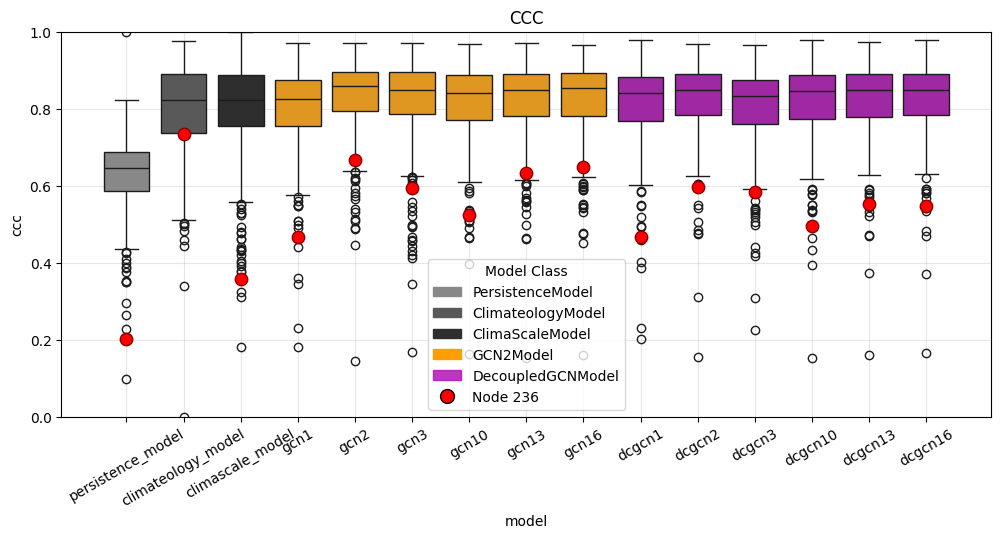

In [ ]:
model_evaluation.plotter.plot_metric(0,'test', 'ccc',plot_type = 'box', log=False, vmin = 0, vmax = 1, highlight_node=236).show()

computing metrics nodewise:   0%|                                                                                                                                                    | 0/1600 [00:00<?, ?it/s]

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [00:02<00:00, 758.07it/s]


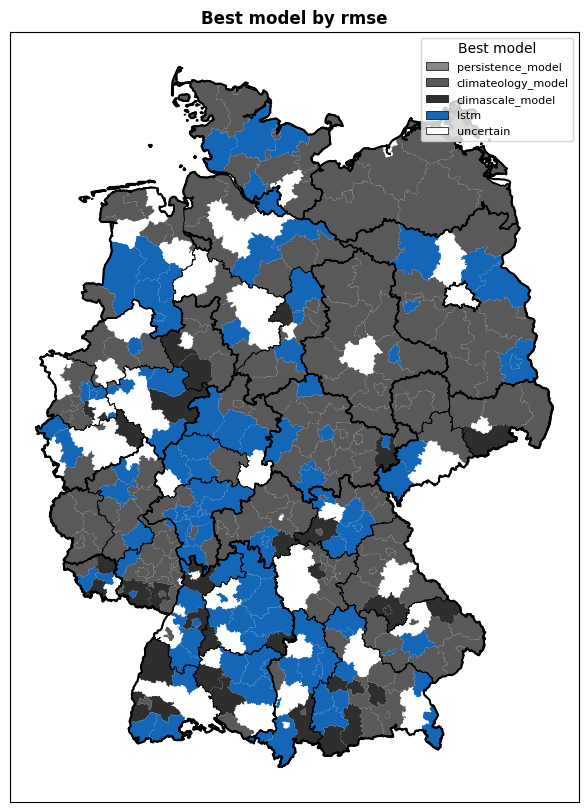

In [ ]:
model_evaluation2 = Evaluator(baseline_models+[lstm]).add_evaluation()
model_evaluation2.plotter.plot_metric(0,'test','rmse', plot_type='best_map', margin_fraction=0.01, reverse_scale=True).show()

computing metrics nodewise:   0%|                                                                                                                                                    | 0/2000 [00:00<?, ?it/s]

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 760.38it/s]


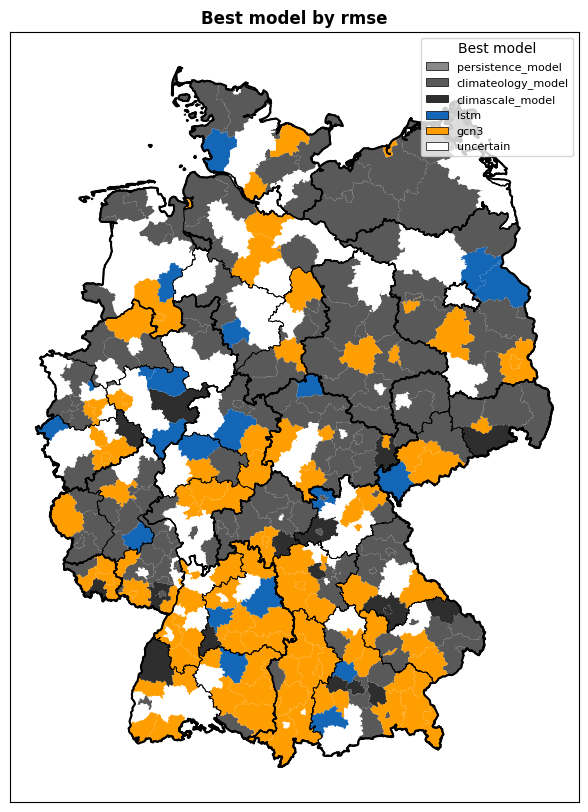

In [ ]:
model_evaluation2 = Evaluator(baseline_models+[lstm,gcn3]).add_evaluation()
model_evaluation2.plotter.plot_metric(0,'test','rmse', plot_type='best_map', margin_fraction=0.01, reverse_scale=True).show()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [00:02<00:00, 755.10it/s]


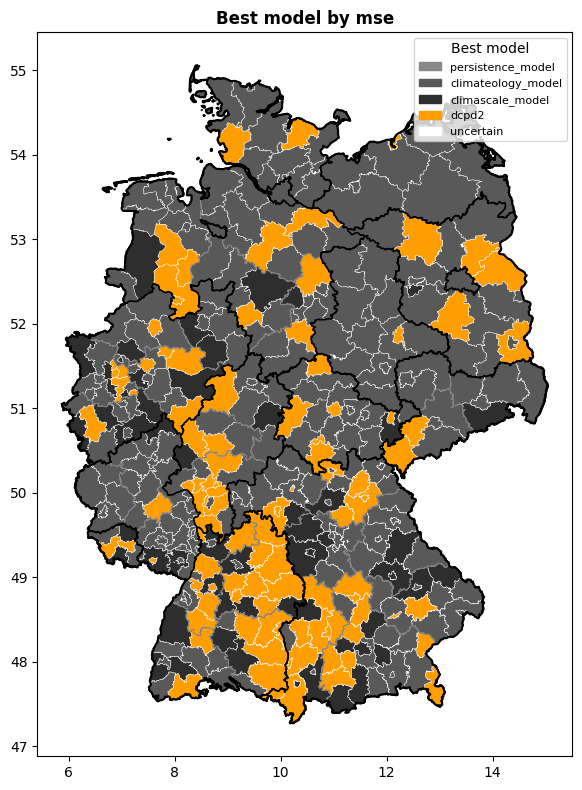

In [ ]:
model_evaluation3 = Evaluator(baseline_models+[dcpd2]).add_evaluation()
model_evaluation3.plotter.plot_single_metric('mse',0, plot_type='best_map',margin_sd=0, best_lowest=True).show()

  0%|                                                                                                                                                                                | 0/1200 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:01<00:00, 745.66it/s]


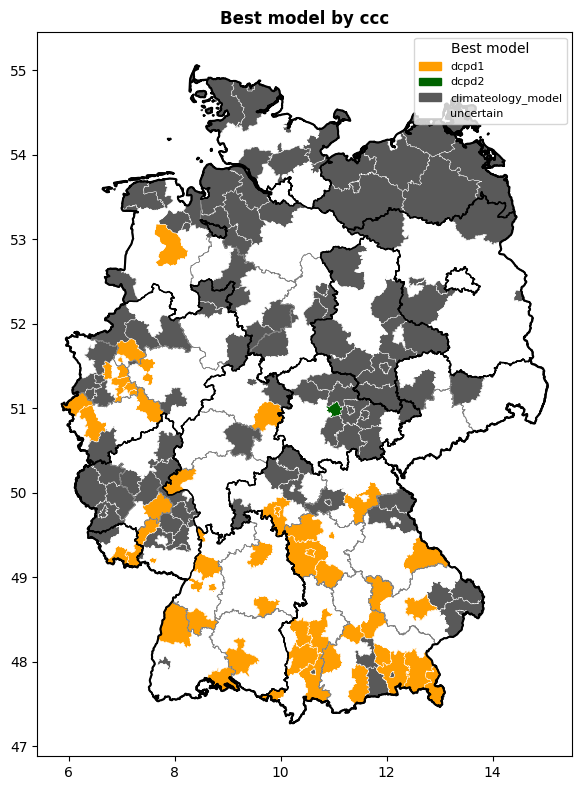

In [ ]:
dcpd2.model_color = 'darkgreen'

model_evaluation3 = Evaluator([dcpd, dcpd2, climateology]).add_evaluation()
model_evaluation3.plotter.plot_single_metric('ccc',0, plot_type='best_map',margin_sd=1, best_lowest=False).show()

In [ ]:
df = model_evaluation.data_compilation.get_data(0,'test')['metrics']

metric = 'ccc'

df_wide = df[['node','model','ccc']]
df_wide = df_wide.pivot_table(index = 'node', columns = 'model', values = 'ccc').reset_index(drop = False)


In [ ]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(df_wide['gcn2'], df_wide['gcn1'], alternative='greater')  # 'less' if lower is better
print(f"U={stat}, p={p}")

U=91688.0, p=0.00010262352028011723


In [ ]:
from scipy.stats import kruskal

stat, p = kruskal(df_wide['dcpd1'], df_wide['dcpd2'], df_wide['climateology_model'])
print(f"H={stat}, p={p}")

H=19.603294326669584, p=5.536033677362336e-05


In [ ]:
from itertools import combinations
from scipy.stats import mannwhitneyu

models = ['dcpd1', 'dcpd2', 'climateology_model']  # your model columns
alpha = 0.05
pairs = list(combinations(models, 2))

for a, b in pairs:
    x = df_wide[a].dropna()
    y = df_wide[b].dropna()
    stat, p = mannwhitneyu(x, y, alternative='greater')  # 'greater' if higher is better
    sig = '***' if p < alpha/len(pairs) else ''
    print(f"{a} vs {b}: U={stat:.1f}, p={p:.3e} {sig}")

dcpd1 vs dcpd2: U=94716.0, p=1.721e-06 ***
dcpd1 vs climateology_model: U=86261.0, p=2.040e-02 
dcpd2 vs climateology_model: U=73259.0, p=9.743e-01 


In [ ]:
"""
spatial_autocorrelation.py
==========================
Moran's I analysis built entirely from your evaluator and models.
No graph constructor required.

Usage
-----
    from spatial_autocorrelation import run_spatial_analysis

    results = run_spatial_analysis(
        evaluator   = evaluator,
        name_geo    = 'your_geo_model_name',   # key in evaluator.evaluated_models
        name_id     = 'your_identity_model_name',
        dataset     = 'test',
        horizon     = 0,
    )
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from typing import Tuple, Dict


# =============================================================================
# 1. BUILD WEIGHT MATRIX FROM SHAPEDATA
# =============================================================================

def build_weight_matrix_from_shapedata(shapedata: gpd.GeoDataFrame,
                                       id_col: str) -> Tuple[np.ndarray, list]:
    """
    Build a row-standardised spatial weight matrix W purely from
    shapedata geometry — no RawGraphConstructor needed.

    Two polygons are neighbors if they 'touch' (share a border edge),
    which is exactly what _geographic_neighbors() does internally.

    Parameters
    ----------
    shapedata : gpd.GeoDataFrame  — model.context_data.shapedata_node
    id_col    : str               — model.epiconfig.id_column

    Returns
    -------
    W          : np.ndarray [num_nodes, num_nodes] — row-standardised
    node_order : list — sorted node ids, matching row/col order of W
    """
    gdf         = shapedata[[id_col, 'geometry']].sort_values(id_col).reset_index(drop=True)
    gdf         = gdf[gdf[id_col].notna()].reset_index(drop=True)
    node_order  = gdf[id_col].tolist()
    node_idx    = {nid: i for i, nid in enumerate(node_order)}
    n           = len(node_order)

    W = np.zeros((n, n), dtype=float)

    neighbors = gpd.sjoin(gdf, gdf, how='inner', predicate='touches')
    neighbors = neighbors[neighbors[f'{id_col}_left'].notna() & neighbors[f'{id_col}_right'].notna()]
    neighbors = neighbors[neighbors[f'{id_col}_left'] != neighbors[f'{id_col}_right']]

    for _, row in neighbors.iterrows():
        i = node_idx[row[f'{id_col}_left']]
        j = node_idx[row[f'{id_col}_right']]
        W[i, j] = 1.0

    # Row-standardise: each row sums to 1; isolated nodes stay zero
    row_sums = W.sum(axis=1, keepdims=True)
    W = np.where(row_sums > 0, W / row_sums, 0.0)

    return W, node_order


# =============================================================================
# 2. GLOBAL MORAN'S I + PERMUTATION TEST
# =============================================================================

def morans_i(values: np.ndarray, W: np.ndarray) -> float:
    """
    Global Moran's I:  I = (n / sum(W)) * (z'Wz / z'z)

    > 0 : neighbors tend to be similar (spatial clustering)
    ~ 0 : random
    < 0 : neighbors tend to be dissimilar
    """
    n           = len(values)
    z           = values - values.mean()
    numerator   = n * float(z @ W @ z)
    denominator = float(z @ z) * W.sum()
    return float('nan') if denominator == 0 else numerator / denominator


def morans_i_permutation_test(values: np.ndarray,
                              W: np.ndarray,
                              n_permutations: int = 999,
                              seed: int = 42) -> Tuple[float, float]:
    """
    Significance via random permutation.
    p-value = fraction of permutations where permuted I >= observed I.
    """
    rng         = np.random.default_rng(seed)
    observed    = morans_i(values, W)
    count_geq   = sum(
        morans_i(rng.permutation(values), W) >= observed
        for _ in range(n_permutations)
    )
    p_value = (count_geq + 1) / (n_permutations + 1)
    return observed, p_value


# =============================================================================
# 3. LOCAL MORAN'S I (LISA)
# =============================================================================

def local_morans_i(values: np.ndarray, W: np.ndarray) -> np.ndarray:
    """
    Local Moran's I per node:  I_i = z_i * (W @ z)_i / var(z)

    High positive  => node and neighbors are both high or both low (cluster)
    High negative  => node is surrounded by dissimilar neighbors (outlier)
    """
    z     = values - values.mean()
    var_z = np.var(z)
    if var_z == 0:
        return np.zeros(len(values))
    return (z * (W @ z)) / var_z


# =============================================================================
# 4. EXTRACT DATA FROM EVALUATOR / MODELS
# =============================================================================

def _get_preds(model, dataset: str, horizon: int) -> pd.DataFrame:
    return model.predictions.get_preds(dataset).get(
        horizon=horizon, is_original=True, spatially_aggregated=False
    )


def extract_targets(model, dataset: str, horizon: int) -> pd.DataFrame:
    time_col = model.epiconfig.temporal_column
    id_col   = model.epiconfig.id_column
    df       = _get_preds(model, dataset, horizon)
    return df[[time_col, id_col, 'target']].copy()


def extract_node_mean_incidence(model, dataset: str,
                                horizon: int, node_order: list) -> np.ndarray:
    id_col = model.epiconfig.id_column
    df     = extract_targets(model, dataset, horizon)
    return df.groupby(id_col)['target'].mean().reindex(node_order).values.astype(float)


def extract_peak_week_incidence(model, dataset: str,
                                horizon: int, node_order: list) -> Tuple[np.ndarray, object]:
    time_col  = model.epiconfig.temporal_column
    id_col    = model.epiconfig.id_column
    df        = extract_targets(model, dataset, horizon)
    peak_week = df.groupby(time_col)['target'].sum().idxmax()
    vals      = (
        df[df[time_col] == peak_week]
        .set_index(id_col)['target']
        .reindex(node_order)
        .values.astype(float)
    )
    return vals, peak_week


def extract_node_improvement(model_geo, model_id,
                             dataset: str, horizon: int,
                             node_order: list) -> pd.DataFrame:
    """
    Per-node mean absolute error, merged on [time_col, id_col] to be safe
    against any ordering differences between models.

    improvement > 0  =>  geo model is better on that node
    """
    time_col = model_geo.epiconfig.temporal_column
    id_col   = model_geo.epiconfig.id_column

    df_geo = _get_preds(model_geo, dataset, horizon)[[time_col, id_col, 'target', 'pred']]
    df_id  = (_get_preds(model_id, dataset, horizon)[[time_col, id_col, 'pred']]
              .rename(columns={'pred': 'pred_id'}))

    df = df_geo.merge(df_id, on=[time_col, id_col]).rename(columns={'pred': 'pred_geo'})
    df['ae_geo']      = (df['target'] - df['pred_geo']).abs()
    df['ae_id']       = (df['target'] - df['pred_id']).abs()
    df['improvement'] = df['ae_id'] - df['ae_geo']

    return (
        df.groupby(id_col)[['ae_geo', 'ae_id', 'improvement']]
        .mean()
        .reindex(node_order)
        .reset_index()
    )


def weekly_morans_i(model, dataset: str, horizon: int,
                    W: np.ndarray, node_order: list) -> pd.DataFrame:
    """Moran's I computed independently for every week."""
    time_col = model.epiconfig.temporal_column
    id_col   = model.epiconfig.id_column
    df       = extract_targets(model, dataset, horizon)

    # Diagnose alignment between prediction node ids and node_order
    pred_nodes = set(df[id_col].unique())
    W_nodes    = set(node_order)
    if pred_nodes != W_nodes:
        only_in_preds = pred_nodes - W_nodes
        only_in_W     = W_nodes - pred_nodes
        print(f"  WARNING: node id mismatch.")
        print(f"    In predictions but not W : {len(only_in_preds)} nodes — e.g. {list(only_in_preds)[:3]}")
        print(f"    In W but not predictions : {len(only_in_W)} nodes — e.g. {list(only_in_W)[:3]}")

    results = []
    skipped_nan = 0
    skipped_var = 0

    for timestamp, week_df in df.groupby(time_col):
        vals = (week_df.set_index(id_col)['target']
                       .reindex(node_order).values.astype(float))
        if np.isnan(vals).any():
            skipped_nan += 1
            # fill NaN with the week mean so the week isn't lost entirely
            vals = np.where(np.isnan(vals), np.nanmean(vals), vals)
        if np.nanstd(vals) == 0:
            skipped_var += 1
            continue
        results.append({'timestamp': timestamp, 'morans_i': morans_i(vals, W)})

    if skipped_nan:
        print(f"  {skipped_nan} weeks had NaN nodes (filled with week mean)")
    if skipped_var:
        print(f"  {skipped_var} weeks skipped (zero variance)")

    if not results:
        raise ValueError(
            "No weeks produced a valid Moran's I. "
            "Check that node ids in predictions match those in shapedata. "
            f"Prediction id sample: {list(pred_nodes)[:5]}, "
            f"node_order sample: {node_order[:5]}"
        )

    return pd.DataFrame(results).sort_values('timestamp').reset_index(drop=True)


# =============================================================================
# 5. PLOTS
# =============================================================================

def _plot_weekly(weekly_df, ax):
    ax.plot(weekly_df['timestamp'], weekly_df['morans_i'],
            color='steelblue', linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title("Global Moran's I per week")
    ax.set_xlabel("Week")
    ax.set_ylabel("Moran's I")
    ax.tick_params(axis='x', rotation=45)


def _plot_lisa_map(local_I, shapedata, id_col, node_order, title, ax):
    lisa_df  = pd.DataFrame({id_col: node_order, 'local_I': local_I})
    gdf_plot = shapedata.merge(lisa_df, on=id_col, how='left')
    vmax     = np.abs(local_I[~np.isnan(local_I)]).max()
    norm     = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    gdf_plot.plot(column='local_I', cmap='RdBu_r', norm=norm,
                  edgecolor='grey', linewidth=0.2, ax=ax, legend=True)
    ax.set_title(title)
    ax.axis('off')


def _plot_scatter(node_errors, local_I, id_col, node_order, ax):
    lisa_df = pd.DataFrame({id_col: node_order, 'local_I': local_I})
    merged  = node_errors.merge(lisa_df, on=id_col)
    ax.scatter(merged['local_I'], merged['improvement'],
               alpha=0.5, s=20, color='steelblue', edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    r = np.corrcoef(merged['local_I'], merged['improvement'])[0, 1]
    ax.set_title(f"Local Moran's I vs. geo improvement  (r = {r:.3f})")
    ax.set_xlabel("Local Moran's I (mean incidence)")
    ax.set_ylabel("MAE improvement: identity − geo")
    return r


# =============================================================================
# 6. MAIN ENTRY POINT
# =============================================================================

def run_spatial_analysis(evaluator,
                         name_geo:       str,
                         name_id:        str,
                         dataset:        str = 'test',
                         horizon:        int = 0,
                         n_permutations: int = 999) -> Dict:
    """
    Full spatial autocorrelation analysis from an Evaluator.

    Parameters
    ----------
    evaluator       : your Evaluator object
    name_geo        : name of the geographic-graph model (key in evaluator.evaluated_models)
    name_id         : name of the identity-graph model
    dataset         : 'train', 'val', or 'test'
    horizon         : forecast horizon index
    n_permutations  : permutation test iterations for significance

    Returns
    -------
    dict with W, node_order, Moran's I values, weekly df, local I arrays, node errors
    Also saves figure to spatial_autocorrelation.png
    """
    model_geo = evaluator.evaluated_models[name_geo]
    model_id  = evaluator.evaluated_models[name_id]
    id_col    = model_geo.epiconfig.id_column
    shapedata = model_geo.context_data.shapedata_node

    print("Building spatial weight matrix from shapedata geometry...")
    W, node_order = build_weight_matrix_from_shapedata(shapedata, id_col)
    print(f"  {len(node_order)} nodes, {int(W.astype(bool).sum())} neighbor pairs")

    mean_inc            = extract_node_mean_incidence(model_geo, dataset, horizon, node_order)
    peak_inc, peak_week = extract_peak_week_incidence(model_geo, dataset, horizon, node_order)
    print(f"  Peak week: {peak_week}")

    print(f"\nPermutation test ({n_permutations} iterations)...")
    I_mean, p_mean = morans_i_permutation_test(mean_inc, W, n_permutations)
    I_peak, p_peak = morans_i_permutation_test(peak_inc, W, n_permutations)

    print(f"\n{'='*54}")
    print(f"  Global Moran's I — mean incidence : {I_mean:+.4f}  (p = {p_mean:.4f})")
    print(f"  Global Moran's I — peak week      : {I_peak:+.4f}  (p = {p_peak:.4f})")
    print(f"{'='*54}")
    if   I_mean > 0.05 and p_mean < 0.05:
        print("  >> Significant positive spatial autocorrelation.")
        print("     Geographic graph is supported by the data.")
    elif p_mean >= 0.05:
        print("  >> No significant spatial autocorrelation detected.")
    else:
        print("  >> Weak or ambiguous spatial signal.")

    local_I_mean = local_morans_i(mean_inc, W)
    local_I_peak = local_morans_i(peak_inc, W)

    print("\nComputing weekly Moran's I...")
    weekly_df = weekly_morans_i(model_geo, dataset, horizon, W, node_order)

    print("Computing per-node improvement (geo vs identity)...")
    node_errors = extract_node_improvement(model_geo, model_id, dataset, horizon, node_order)
    pct_better  = (node_errors['improvement'] > 0).mean() * 100
    print(f"  Geo model better on {pct_better:.1f}% of nodes")

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    _plot_weekly(weekly_df, axes[0, 0])
    _plot_lisa_map(local_I_mean, shapedata, id_col, node_order,
                   "Local Moran's I — mean incidence", axes[0, 1])
    _plot_lisa_map(local_I_peak, shapedata, id_col, node_order,
                   f"Local Moran's I — peak week ({peak_week})", axes[1, 0])
    r = _plot_scatter(node_errors, local_I_mean, id_col, node_order, axes[1, 1])

    fig.suptitle(
        f"Spatial Autocorrelation  |  {name_geo} vs {name_id}  |  {dataset}, horizon={horizon}\n"
        f"Global Moran's I (mean): {I_mean:+.3f} (p={p_mean:.3f})  |  "
        f"Geo better on {pct_better:.0f}% of nodes  |  r(LISA, improvement) = {r:.3f}",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig('spatial_autocorrelation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nFigure saved → spatial_autocorrelation.png")

    return {
        'W'            : W,
        'node_order'   : node_order,
        'I_mean'       : I_mean,
        'p_mean'       : p_mean,
        'I_peak'       : I_peak,
        'p_peak'       : p_peak,
        'local_I_mean' : local_I_mean,
        'local_I_peak' : local_I_peak,
        'weekly_df'    : weekly_df,
        'node_errors'  : node_errors,
    }

In [ ]:
evaluator

NameError: name 'evaluator' is not defined

Building spatial weight matrix from shapedata geometry...
  400 nodes, 2088 neighbor pairs
  Peak week: 2020-03-02 00:00:00

Permutation test (999 iterations)...

  Global Moran's I — mean incidence : +0.6847  (p = 0.0010)
  Global Moran's I — peak week      : +0.4336  (p = 0.0010)
  >> Significant positive spatial autocorrelation.
     Geographic graph is supported by the data.

Computing weekly Moran's I...
Computing per-node improvement (geo vs identity)...
  Geo model better on 58.5% of nodes


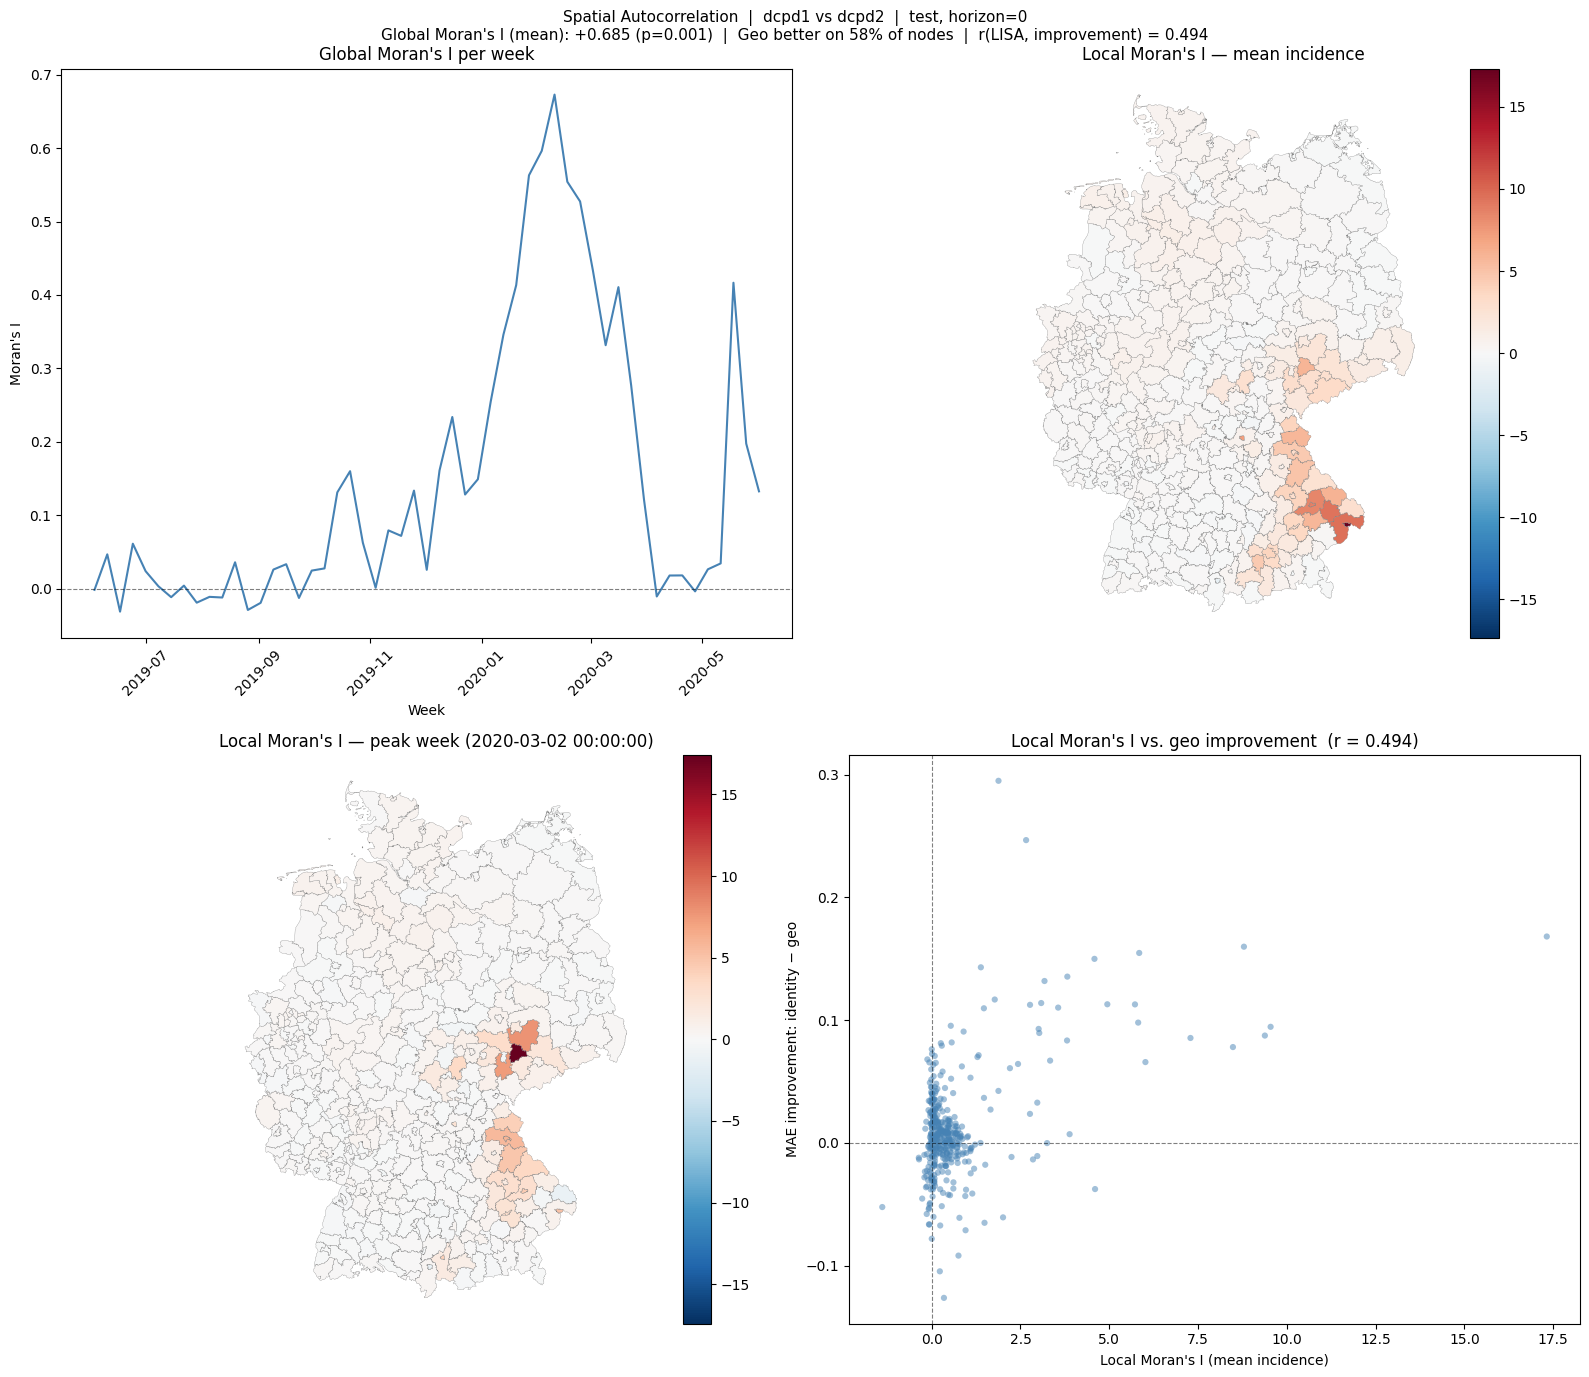


Figure saved → spatial_autocorrelation.png


In [ ]:

results = run_spatial_analysis(
    evaluator = ev,
    name_geo  = 'dcpd1',  # exact key in evaluator.evaluated_models
    name_id   = 'dcpd2',
    dataset   = 'test',
    horizon   = 0,
)